# XGBoost — pronóstico del precio de bolsa

Primer modelo de la comparación. Las features salen del modelo ganador de la
etapa 3 (`salidas_seleccion/modelo_final.json`), elegido con walk-forward sobre
la validación 2020-2022, **sin tocar el periodo de prueba**.

**Periodos del pipeline**

| Paso | Qué hace | Periodo |
|---|---|---|
| Etapa 01 | Selección de variables | 2015-2019 |
| Etapas 02-03 | Elección de bloques con Diebold-Mariano | validación 2020-2022 |
| Nivel 1 | Split principal | desarrollo 2015-2022 · prueba 2023-2025 |
| Nivel 2 | CV expansiva para hiperparámetros | solo dentro de desarrollo |
| Nivel 3 | Walk-forward con recalibración | sobre prueba, hiperparámetros congelados |

Reglas que no se rompen:
- Nunca `KFold` aleatorio — todo split es cronológico.
- Los hiperparámetros se eligen **solo** con datos ≤ 2022-12-31 y se congelan.
- Gap de 30 días entre train y validación (los features usan ventanas de 30d).
- El periodo de prueba solo se toca en el nivel 3, para medir.
- Toda tabla incluye el **pronóstico ingenuo** (precio de ayer) y su prueba DM.
- Acierto direccional con una sola definición en todo el proyecto:
  `signo(y_t − y_{t−1}) == signo(ŷ_t − y_{t−1})`, con `y_{t−1}` observado.

In [1]:
import warnings, time, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (13, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("xgboost", xgb.__version__)

xgboost 3.4.1


## 1. Configuración

In [2]:
BASE = Path(r"C:\Users\andre\OneDrive\cosas de la universidad\Uniandes\VIII\Tesis")

CONFIG = {
    "panel_path":        BASE / "data" / "panel_d.parquet",
    "modelo_final_json": BASE / "salidas_seleccion" / "modelo_final.json",
    "out_dir":           BASE / "salidas_modelos",
    "target_col": "precio_ponderado",
    "log_target": True,

    # Nivel 1
    "dev_end":    "2022-12-31",
    "test_start": "2023-01-01",
    "test_end":   "2025-12-31",

    # Gap entre train y validación (= ventana más larga de los features)
    "gap_days": 30,

    # Nivel 2
    "n_splits_cv": 5,

    # Nivel 3
    "refit_every": 30,
    "min_train":   730,
    "horizon":     1,

    "seed": 42,
}

NOMBRE_INGENUO = "Ingenuo (precio ayer)"

# RESPALDO: solo se usa si falta modelo_final.json
FEATURES_RESPALDO = {
    "AR": ["log_precio_lag1", "log_precio_ma30", "log_precio_sd7"],
    "HIDRO": [
        "aportes_pct_sistema_lag1", "aportes_por_rio_lag2",
        "aportes_media_hist_lag30", "volumen_util_pct_lag1",
        "inv_volumen_util_pct_lag1", "volumen_util_pct_emb_d7", "oni_lag1",
    ],
    "OFERTA": [
        "disp_declarada_lag0",   # reemplaza a disp_comercial_lag0 (se ajusta ex post)
        "margen_reserva_lag0", "margen_reserva_lag7",
        "disp_declarada_d7", "gen_programada_lag7",
    ],
}

def cargar_modelo_final(cfg, respaldo):
    """
    Lee las features del modelo elegido en la etapa 3 (validacion 2020-2022).
    Si falta el archivo usa 'respaldo' y avisa: lo correcto es correr 03.
    """
    ruta = Path(cfg["modelo_final_json"])
    if not ruta.exists():
        print(f"[!] No encuentro {ruta}.\n    Uso las features de RESPALDO. "
              f"Corre 03_bloques_candidatos.py para que salgan del pipeline.")
        return respaldo, None
    info = json.loads(ruta.read_text(encoding="utf-8"))
    val_fin = pd.Timestamp(info["ventana_validacion"][1])
    if val_fin >= pd.Timestamp(cfg["test_start"]):
        raise ValueError(
            f"La etapa 3 eligio el modelo con datos hasta {val_fin.date()}, "
            f"dentro del periodo de prueba. Corrige 01/03 antes de seguir.")
    if info.get("test_start") != cfg["test_start"]:
        print(f"[!] test_start del pipeline ({info.get('test_start')}) "
              f"distinto al de este notebook ({cfg['test_start']})")
    print(f"Modelo de la etapa 3: {info['modelo']}")
    print(f"  criterio:   {info['criterio']}")
    print(f"  validacion: {info['ventana_validacion'][0]} -> "
          f"{info['ventana_validacion'][1]}")
    return info["bloques"], info


FEATURES, INFO_MODELO = cargar_modelo_final(CONFIG, FEATURES_RESPALDO)
TODAS = list(dict.fromkeys(f for lst in FEATURES.values() for f in lst))
print(f"{len(TODAS)} features en {len(FEATURES)} bloques: "
      + ", ".join(f"{b}={len(c)}" for b, c in FEATURES.items()))

Modelo de la etapa 3: AR+HIDRO+OFERTA
  criterio:   menor MAPE en validacion entre los modelos que mejoran la base AR con DM<0 y p_FDR<0.05
  validacion: 2020-01-01 -> 2022-12-31
15 features en 3 bloques: AR=3, HIDRO=7, OFERTA=5


## 2. Carga del panel y construcción de features

Todas las estadísticas móviles usan `shift(1)` antes del rolling, así que ninguna feature ve el mismo día ni el futuro. La construcción sigue la misma convención de nombres que la etapa 01.

In [3]:
def cargar_panel(cfg):
    p = Path(cfg["panel_path"])
    df = pd.read_parquet(p) if p.suffix == ".parquet" else pd.read_csv(p)
    if "fecha" in df.columns:
        df["fecha"] = pd.to_datetime(df["fecha"]); df = df.set_index("fecha")
    else:
        df.index = pd.to_datetime(df.index)
    return df.sort_index().asfreq("D")


def construir(df, cfg):
    """Construye SOLO las features del modelo final, no las ~400 de la selección."""
    # Transformación convexa de reservas (no está en el panel)
    if "volumen_util_pct" in df.columns and "inv_volumen_util_pct" not in df.columns:
        v = pd.to_numeric(df["volumen_util_pct"], errors="coerce")
        piso = 0.02 if v.max() <= 1.5 else 2.0
        df["inv_volumen_util_pct"] = 1.0 / v.clip(lower=piso)
        print(f"  inv_volumen_util_pct creada (piso {piso})")

    y_raw = pd.to_numeric(df[cfg["target_col"]], errors="coerce")
    y = np.log(y_raw.clip(lower=1e-6)) if cfg["log_target"] else y_raw
    y.name = "y"

    F = {}
    for feat in TODAS:
        # bloque AR: log_precio_lagN, log_precio_maW, log_precio_sdW
        if feat.startswith("log_precio_"):
            suf = feat[len("log_precio_"):]
            if suf.startswith("lag"):
                F[feat] = y.shift(int(suf[3:]))
            elif suf.startswith("ma"):
                w = int(suf[2:])
                F[feat] = y.shift(1).rolling(w, min_periods=(w + 1) // 2).mean()
            elif suf.startswith("sd"):
                w = int(suf[2:])
                F[feat] = y.shift(1).rolling(w, min_periods=(w + 1) // 2).std()
            continue

        # exógenas: <col>_lagN  y  <col>_d7
        if feat.endswith("_d7"):
            base = feat[:-3]
            if base in df.columns:
                s = pd.to_numeric(df[base], errors="coerce")
                F[feat] = s.shift(1) - s.shift(8)
        elif "_lag" in feat:
            base, lag = feat.rsplit("_lag", 1)
            if base in df.columns:
                s = pd.to_numeric(df[base], errors="coerce")
                F[feat] = s if int(lag) == 0 else s.shift(int(lag))

    X = pd.DataFrame(F, index=df.index)
    faltan = [f for f in TODAS if f not in X.columns]
    if faltan:
        print(f"  [!] FALTAN (revisa el panel): {faltan}")
    return X[[f for f in TODAS if f in X.columns]], y, y_raw


df = cargar_panel(CONFIG)
print(f"panel: {df.shape[0]} filas x {df.shape[1]} cols  "
      f"{df.index.min().date()} -> {df.index.max().date()}")

X, y, y_niv = construir(df, CONFIG)
print(f"features: {X.shape}")
print(f"cobertura media: {X.notna().mean().mean():.1%}")
X.tail(3)

panel: 4018 filas x 58 cols  2015-01-01 -> 2025-12-31
  inv_volumen_util_pct creada (piso 0.02)
features: (4018, 15)
cobertura media: 99.9%


,log_precio_lag1,log_precio_ma30,log_precio_sd7,aportes_pct_sistema_lag1,aportes_por_rio_lag2,aportes_media_hist_lag30,volumen_util_pct_lag1,inv_volumen_util_pct_lag1,volumen_util_pct_emb_d7,oni_lag1,disp_declarada_lag0,margen_reserva_lag0,margen_reserva_lag7,disp_declarada_d7,gen_programada_lag7
fecha,,,,,,,,,,,,,,,
2025-12-29,5.665523,5.574563,0.285772,0.71144,1.456842e+08,270490000.0,0.81323,1.229664,-0.013506,-0.57,1.804394e+07,0.100151,0.098408,683778.75,2.400569e+08
2025-12-30,5.773723,5.583342,0.234641,0.64995,1.404390e+08,270490000.0,0.80913,1.235895,-0.016095,-0.57,1.810440e+07,0.091872,0.089373,424762.50,2.399645e+08
2025-12-31,5.702553,5.588235,0.146841,0.64963,1.282993e+08,197400000.0,0.80542,1.241588,-0.016978,-0.57,1.776013e+07,0.092511,0.088826,272032.50,2.253807e+08


## 3. Nivel 1 — split principal

El periodo de prueba no se toca hasta el nivel 3.

DESARROLLO  2015-01-01 -> 2022-12-31  (2922 días, 73%)
PRUEBA      2023-01-01 -> 2025-12-31  (1096 días, 27%)


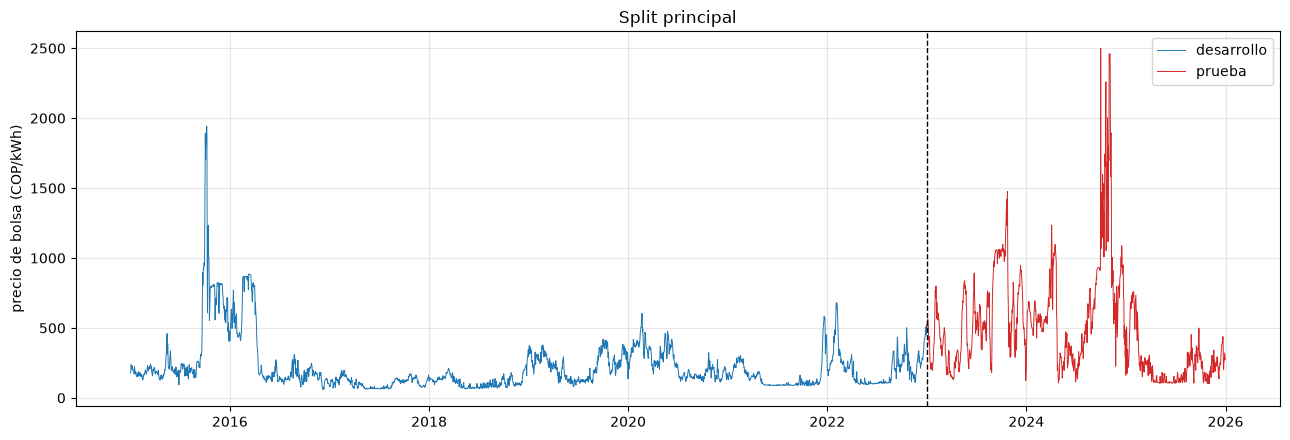

In [4]:
dev_end = pd.Timestamp(CONFIG["dev_end"])
test_ini = pd.Timestamp(CONFIG["test_start"])
test_fin = pd.Timestamp(CONFIG["test_end"])

X_dev, y_dev = X.loc[:dev_end], y.loc[:dev_end]
X_test, y_test = X.loc[test_ini:test_fin], y.loc[test_ini:test_fin]

print(f"DESARROLLO  {X_dev.index.min().date()} -> {X_dev.index.max().date()}  "
      f"({len(X_dev)} días, {len(X_dev)/len(X):.0%})")
print(f"PRUEBA      {X_test.index.min().date()} -> {X_test.index.max().date()}  "
      f"({len(X_test)} días, {len(X_test)/len(X):.0%})")

fig, ax = plt.subplots()
ax.plot(y_niv.loc[:dev_end], lw=.7, label="desarrollo")
ax.plot(y_niv.loc[test_ini:test_fin], lw=.7, color="tab:red", label="prueba")
ax.axvline(dev_end, color="k", ls="--", lw=1)
ax.set_ylabel("precio de bolsa (COP/kWh)"); ax.legend(); ax.set_title("Split principal")
plt.tight_layout(); plt.show()

## 4. Nivel 2 — CV expansiva para hiperparámetros

`TimeSeriesSplit` con `gap` de 30 días: sin ese espacio, las observaciones
justo al borde entre train y validación comparten información por las ventanas
móviles y la validación queda contaminada.

Búsqueda aleatoria sobre un espacio acotado — con 5 folds y ~2900 días, un grid
exhaustivo no aporta más que ruido.

In [5]:
def mape_log(y_true_log, y_pred_log):
    """MAPE en NIVELES, no en log — es lo interpretable en COP/kWh."""
    a, p = np.exp(y_true_log), np.exp(y_pred_log)
    return float(np.mean(np.abs((a - p) / a)) * 100)


ESPACIO = {
    "n_estimators":     [200, 400, 600, 800],
    "max_depth":        [3, 4, 5, 6, 8],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "subsample":        [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 10, 20],
    "reg_lambda":       [0.5, 1.0, 3.0, 10.0],
}

def muestrear(rng):
    return {k: rng.choice(v).item() for k, v in ESPACIO.items()}


def cv_score(params, X_dev, y_dev, cfg, n_splits=5):
    """MAPE promedio sobre los folds expansivos. Solo datos de desarrollo."""
    d = pd.concat([X_dev, y_dev], axis=1).dropna()
    if len(d) < 500:
        return np.inf, []
    Xd, yd = d[X_dev.columns].values, d["y"].values

    tscv = TimeSeriesSplit(n_splits=n_splits, gap=cfg["gap_days"])
    scores = []
    for tr, va in tscv.split(Xd):
        m = xgb.XGBRegressor(**params, random_state=cfg["seed"],
                             n_jobs=-1, tree_method="hist")
        m.fit(Xd[tr], yd[tr])
        scores.append(mape_log(yd[va], m.predict(Xd[va])))
    return float(np.mean(scores)), scores


N_ITER = 30
rng = np.random.default_rng(CONFIG["seed"])
t0 = time.time()
resultados = []

for i in range(N_ITER):
    p = muestrear(rng)
    s, folds = cv_score(p, X_dev, y_dev, CONFIG, CONFIG["n_splits_cv"])
    resultados.append({"iter": i, "mape_cv": s, **p})
    if (i + 1) % 5 == 0:
        mejor = min(r["mape_cv"] for r in resultados)
        print(f"  [{i+1:>2}/{N_ITER}] mejor MAPE CV: {mejor:.3f}%  "
              f"({time.time()-t0:.0f}s)")

busq = pd.DataFrame(resultados).sort_values("mape_cv")
MEJORES = {k: busq.iloc[0][k] for k in ESPACIO}
for k in ("n_estimators", "max_depth", "min_child_weight"):
    MEJORES[k] = int(MEJORES[k])

print(f"\nMejor MAPE en CV: {busq.iloc[0]['mape_cv']:.3f}%")
print("Hiperparámetros congelados:")
for k, v in MEJORES.items():
    print(f"  {k:18s} {v}")
busq.head(5)

  [ 5/30] mejor MAPE CV: 17.280%  (35s)


  [10/30] mejor MAPE CV: 16.598%  (76s)


  [15/30] mejor MAPE CV: 16.025%  (122s)


  [20/30] mejor MAPE CV: 16.025%  (159s)


  [25/30] mejor MAPE CV: 16.025%  (191s)


  [30/30] mejor MAPE CV: 16.025%  (218s)

Mejor MAPE en CV: 16.025%
Hiperparámetros congelados:
  n_estimators       800
  max_depth          3
  learning_rate      0.03
  subsample          0.7
  colsample_bytree   1.0
  min_child_weight   5
  reg_lambda         1.0


,iter,mape_cv,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_lambda
10,10,16.025284,800,3,0.03,0.7,1.0,5,1.0
8,8,16.598203,600,3,0.05,0.9,1.0,10,1.0
12,12,16.692518,600,6,0.01,0.8,1.0,20,1.0
23,23,16.939452,600,5,0.03,0.8,1.0,5,0.5
6,6,17.157595,600,4,0.01,1.0,0.8,20,3.0


## 5. Nivel 3 — walk-forward sobre el periodo de prueba

Hiperparámetros **congelados**; solo se reajustan los pesos cada 30 días con
ventana expansiva. Así se replica una operación real: el día D solo se conoce
lo ocurrido hasta D−1.

Se comparan dos configuraciones de ventana — expansiva (toda la historia) y
deslizante (3 años) — porque con un cambio de régimen fuerte como El Niño 2024
no es obvio cuál gana.

In [6]:
def walk_forward(X, y, params, cfg, ventana="expansiva", años_ventana=3,
                 modelo="xgb", etiqueta=""):
    idx = X.loc[cfg["test_start"]:cfg["test_end"]].index
    preds = pd.Series(index=idx, dtype=float)
    fechas = list(idx)
    bloques = list(range(0, len(fechas), cfg["refit_every"]))
    t0 = time.time()

    for j, i in enumerate(bloques):
        chunk = fechas[i:i + cfg["refit_every"]]
        corte = chunk[0] - pd.Timedelta(days=cfg["horizon"])

        ini = (corte - pd.DateOffset(years=años_ventana)
               if ventana == "deslizante" else X.index.min())
        tr = pd.concat([X.loc[ini:corte], y.loc[ini:corte]], axis=1).dropna()
        if len(tr) < cfg["min_train"]:
            continue

        if modelo == "xgb":
            m = xgb.XGBRegressor(**params, random_state=cfg["seed"],
                                 n_jobs=-1, tree_method="hist")
        else:
            m = RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                                      n_jobs=-1, random_state=cfg["seed"])
        m.fit(tr[X.columns].values, tr["y"].values)

        te = X.loc[chunk].dropna()
        if not te.empty:
            preds.loc[te.index] = m.predict(te.values)

        pct = (j + 1) / len(bloques)
        eta = (time.time() - t0) / pct - (time.time() - t0)
        print(f"\r  {etiqueta:22s} [{j+1:>2}/{len(bloques)}] {pct:4.0%} "
              f"ETA {eta:3.0f}s", end="", flush=True)

    print(f"\r  {etiqueta:22s} [{len(bloques)}/{len(bloques)}] 100%  "
          f"({time.time()-t0:.0f}s)            ")
    err = (y.loc[idx] - preds).rename("error")
    return err, preds


print("Entrenando...")
err_exp, pred_exp = walk_forward(X, y, MEJORES, CONFIG, "expansiva",
                                 etiqueta="XGB expansiva")
err_des, pred_des = walk_forward(X, y, MEJORES, CONFIG, "deslizante",
                                 etiqueta="XGB deslizante 3a")
err_rf,  pred_rf  = walk_forward(X, y, None, CONFIG, "expansiva",
                                 modelo="rf", etiqueta="RF (referencia)")

Entrenando...


  XGB expansiva          [ 1/37]   3% ETA  49s

  XGB expansiva          [ 2/37]   5% ETA  50s

  XGB expansiva          [ 3/37]   8% ETA  50s

  XGB expansiva          [ 4/37]  11% ETA  49s

...

  RF (referencia)        [34/37]  92% ETA   2s

  RF (referencia)        [35/37]  95% ETA   1s

  RF (referencia)        [36/37]  97% ETA   1s

  RF (referencia)        [37/37] 100% ETA  -0s

  RF (referencia)        [37/37] 100%  (25s)            


## 6. Métricas y desglose por régimen

El MAPE agregado puede esconder desempeños opuestos: un modelo excelente en 2023 y pésimo en El Niño 2024 daría un promedio decente y sería inútil en producción.

La primera fila de cada tabla es el **pronóstico ingenuo** (precio de hoy = precio de ayer). Con una serie casi de caminata aleatoria, es la referencia mínima que cualquier modelo debe superar. No predice dirección, así que su acierto direccional queda vacío.

In [7]:
def metricas(y_log, pred_log, y_prev_log):
    """
    MAPE/RMSE/MAE en niveles (COP/kWh) y RMSE en log.

    Acierto direccional (DA) con UNA sola definición en todo el proyecto:
        signo(y_t − y_{t−1}) == signo(ŷ_t − y_{t−1}),  con y_{t−1} OBSERVADO.
    Responde "¿el modelo acierta si mañana sube o baja respecto a hoy?".
    El pronóstico ingenuo (ŷ_t = y_{t−1}) no predice dirección: DA = NaN.
    """
    d = pd.concat([y_log.rename("real"), pred_log.rename("pred"),
                   y_prev_log.rename("prev")], axis=1).dropna()
    if d.empty:
        return {}
    a_n, p_n = np.exp(d["real"]), np.exp(d["pred"])
    mov = d["pred"] - d["prev"]
    da = (float((np.sign(d["real"] - d["prev"]) == np.sign(mov)).mean() * 100)
          if (mov.abs() > 1e-12).any() else np.nan)
    return {
        "n": len(d),
        "MAPE_%":   float((np.abs((a_n - p_n) / a_n)).mean() * 100),
        "RMSE_COP": float(np.sqrt(((a_n - p_n) ** 2).mean())),
        "MAE_COP":  float((a_n - p_n).abs().mean()),
        "RMSE_log": float(np.sqrt(((d["real"] - d["pred"]) ** 2).mean())),
        "DA_%":     da,
    }


# Pronóstico ingenuo: el precio de hoy = el de ayer. Referencia obligatoria.
y_prev = y.shift(CONFIG["horizon"])
idx_test = pred_exp.index
pred_ing = y_prev.reindex(idx_test)
err_ing = (y.reindex(idx_test) - pred_ing).rename("error")

modelos = {NOMBRE_INGENUO: pred_ing, "XGB expansiva": pred_exp,
           "XGB deslizante": pred_des, "RF referencia": pred_rf}
tabla = pd.DataFrame({k: metricas(y, v, y_prev) for k, v in modelos.items()}).T
print("GLOBAL (2023-2025)")
print(tabla.round(3).to_string())

GLOBAL (2023-2025)
                            n  MAPE_%  RMSE_COP  MAE_COP  RMSE_log    DA_%
Ingenuo (precio ayer)  1096.0  12.855   118.061   55.627     0.187     NaN
XGB expansiva          1096.0  12.576   113.315   57.661     0.171  61.861
XGB deslizante         1096.0  14.061   130.943   67.991     0.192  59.580
RF referencia          1096.0  12.953   125.360   60.519     0.180  58.029


In [8]:
# --- regímenes -----------------------------------------------------------
# Se definen sobre el precio REAL observado en prueba (no sobre predicciones).
test_niv = y_niv.loc[CONFIG["test_start"]:CONFIG["test_end"]]
q33, q67 = test_niv.quantile([1/3, 2/3])

regimen = pd.Series("medio", index=test_niv.index)
regimen[test_niv <= q33] = "bajo"
regimen[test_niv >= q67] = "alto"

print(f"Umbrales: bajo <= {q33:.0f}  |  alto >= {q67:.0f} COP/kWh")
print(regimen.value_counts().to_string())

filas = []
for nombre, pred in modelos.items():
    for reg in ["bajo", "medio", "alto"]:
        sel = regimen[regimen == reg].index
        m = metricas(y.loc[sel], pred.reindex(sel), y_prev.loc[sel])
        filas.append({"modelo": nombre, "regimen": reg, **m})
    for año in sorted(test_niv.index.year.unique()):
        sel = test_niv[test_niv.index.year == año].index
        m = metricas(y.loc[sel], pred.reindex(sel), y_prev.loc[sel])
        filas.append({"modelo": nombre, "regimen": str(año), **m})

por_reg = pd.DataFrame(filas)
print("\nPOR RÉGIMEN Y POR AÑO")
print(por_reg.pivot(index="regimen", columns="modelo",
                    values="MAPE_%").round(2).to_string())
print("\nAcierto direccional (%)")
print(por_reg.pivot(index="regimen", columns="modelo",
                    values="DA_%").round(1).to_string())

Umbrales: bajo <= 263  |  alto >= 563 COP/kWh
bajo     366
alto     366
medio    364

POR RÉGIMEN Y POR AÑO
modelo   Ingenuo (precio ayer)  RF referencia  XGB deslizante  XGB expansiva
regimen                                                                     
2023                     10.77          10.75           13.44          10.88
2024                     13.48          13.72           13.52          12.51
2025                     14.32          14.39           15.23          14.33
alto                      8.82           9.64           12.14           9.21
bajo                     16.32          16.19           17.24          15.80
medio                    13.43          13.03           12.80          12.71

Acierto direccional (%)
modelo   Ingenuo (precio ayer)  RF referencia  XGB deslizante  XGB expansiva
regimen                                                                     
2023                       NaN           56.4            57.8           60.0
2024                

## 7. Diebold-Mariano entre modelos

`DM < 0` con `p < 0.05` ⇒ el primer modelo tiene menor pérdida.
Se usa la corrección Harvey-Leybourne-Newbold, necesaria en muestras finitas.

Primero cada modelo contra el **pronóstico ingenuo**; después los modelos entre sí.

In [9]:
def diebold_mariano(e1, e2, h=1, power=2):
    e1, e2 = np.asarray(e1, float), np.asarray(e2, float)
    ok = np.isfinite(e1) & np.isfinite(e2)
    e1, e2 = e1[ok], e2[ok]
    T = len(e1)
    if T < 20:
        return np.nan, np.nan
    d = np.abs(e1) ** power - np.abs(e2) ** power
    dbar = d.mean()
    g0 = np.sum((d - dbar) ** 2) / T
    gs = [np.sum((d[k:] - dbar) * (d[:-k] - dbar)) / T for k in range(1, h)]
    V = (g0 + 2 * sum(gs)) / T
    if V <= 0:
        return np.nan, np.nan
    DM = dbar / np.sqrt(V)
    hln = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    DM *= hln
    return DM, 2 * (1 - stats.t.cdf(abs(DM), df=T-1))


errores = {NOMBRE_INGENUO: err_ing, "XGB expansiva": err_exp,
           "XGB deslizante": err_des, "RF referencia": err_rf}
pares = ([(m, NOMBRE_INGENUO) for m in ["XGB expansiva", "XGB deslizante", "RF referencia"]]
         + [("XGB expansiva", "RF referencia"),
            ("XGB deslizante", "RF referencia"),
            ("XGB expansiva", "XGB deslizante")])

filas_dm = []
for a, b in pares:
    DM, p = diebold_mariano(errores[a], errores[b], h=CONFIG["horizon"])
    if not np.isfinite(DM):
        print(f"{a} vs {b}: no calculable"); continue
    ganador = a if DM < 0 else b
    veredicto = f"gana {ganador}" if p < 0.05 else "sin diferencia significativa"
    print(f"{a:16s} vs {b:22s}  DM {DM:+6.3f}  p {p:.4f}  -> {veredicto}")
    filas_dm.append({"modelo_1": a, "modelo_2": b, "DM": DM, "p": p,
                     "veredicto": veredicto})
tabla_dm = pd.DataFrame(filas_dm)

XGB expansiva    vs Ingenuo (precio ayer)   DM -3.696  p 0.0002  -> gana XGB expansiva
XGB deslizante   vs Ingenuo (precio ayer)   DM +1.055  p 0.2919  -> sin diferencia significativa
RF referencia    vs Ingenuo (precio ayer)   DM -1.822  p 0.0687  -> sin diferencia significativa
XGB expansiva    vs RF referencia           DM -3.605  p 0.0003  -> gana XGB expansiva
XGB deslizante   vs RF referencia           DM +3.417  p 0.0007  -> gana RF referencia
XGB expansiva    vs XGB deslizante          DM -7.569  p 0.0000  -> gana XGB expansiva


## 8. Diagnóstico visual

Mejor por MAPE: XGB expansiva


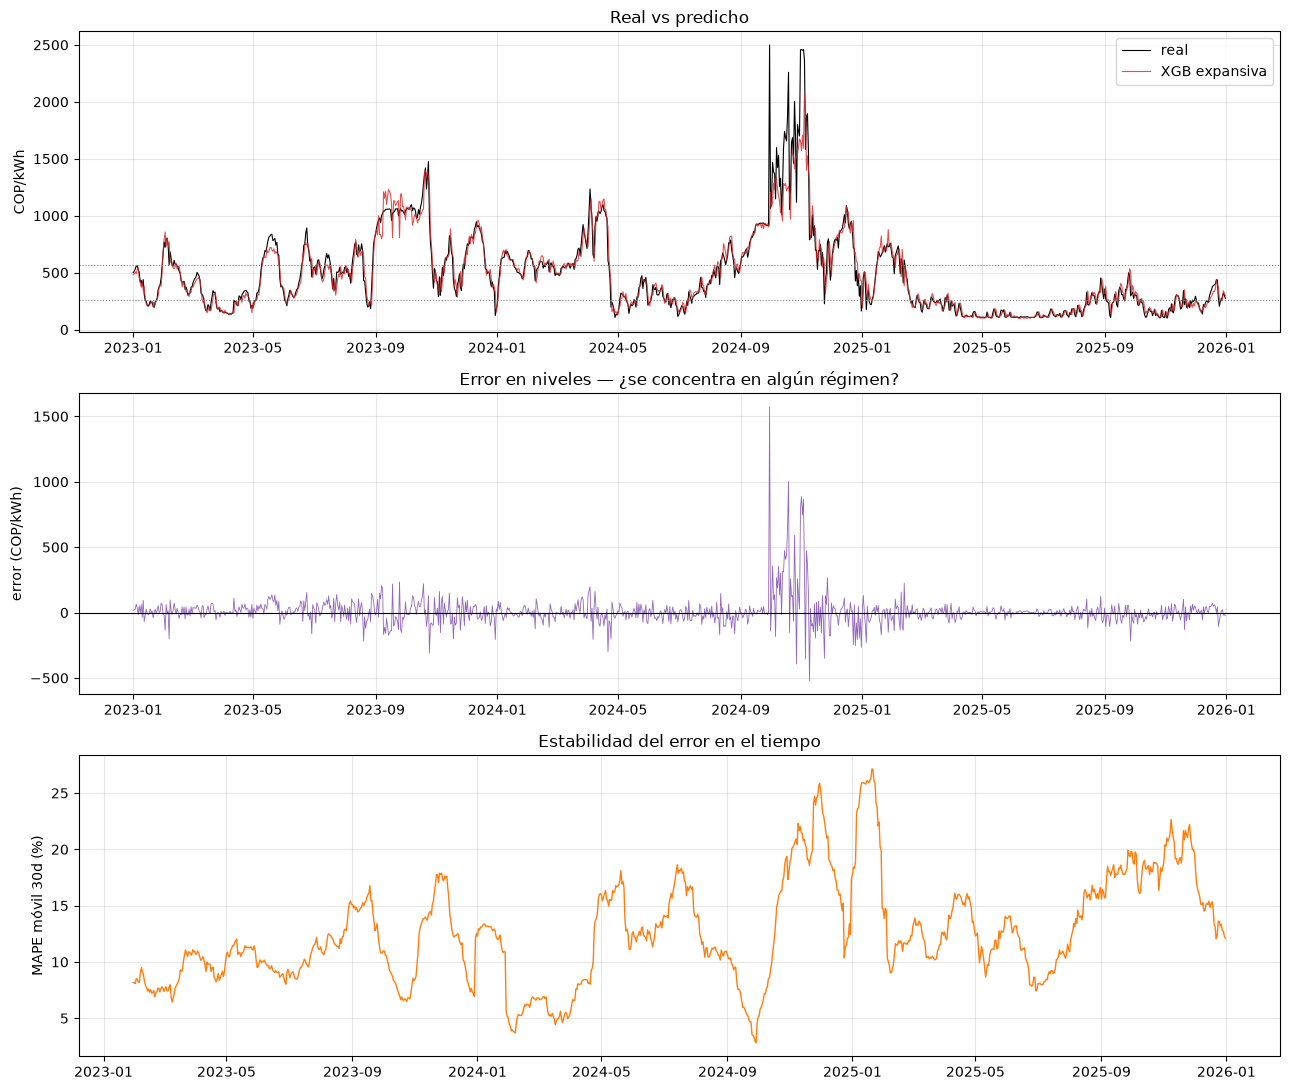

In [10]:
mejor = tabla.drop(index=NOMBRE_INGENUO)["MAPE_%"].idxmin()
pred_mejor = modelos[mejor]
print(f"Mejor por MAPE: {mejor}")

fig, axes = plt.subplots(3, 1, figsize=(13, 11))

ax = axes[0]
ax.plot(test_niv, lw=.8, label="real", color="k")
ax.plot(np.exp(pred_mejor), lw=.8, label=mejor, color="tab:red", alpha=.8)
ax.axhline(q67, ls=":", c="gray", lw=.8); ax.axhline(q33, ls=":", c="gray", lw=.8)
ax.set_ylabel("COP/kWh"); ax.legend(); ax.set_title("Real vs predicho")

ax = axes[1]
e = (test_niv - np.exp(pred_mejor)).dropna()
ax.plot(e, lw=.6, color="tab:purple"); ax.axhline(0, c="k", lw=.8)
ax.set_ylabel("error (COP/kWh)"); ax.set_title("Error en niveles — ¿se concentra en algún régimen?")

ax = axes[2]
ape = (np.abs(e / test_niv.reindex(e.index)) * 100)
ax.plot(ape.rolling(30).mean(), lw=1, color="tab:orange")
ax.set_ylabel("MAPE móvil 30d (%)"); ax.set_title("Estabilidad del error en el tiempo")

plt.tight_layout(); plt.show()

### Extrapolación: días fuera del rango de entrenamiento

Un árbol no puede predecir un valor mayor que lo que vio al entrenar: cada hoja
devuelve un promedio de observaciones pasadas. En la formulación en **nivel**
eso le pone un techo a la predicción. En la formulación en **diferencia** el
cambio predicho se suma al precio observado de ayer, así que el nivel
reconstruido sí puede superar el máximo histórico.

Aquí se marcan los días de prueba en que el precio real superó el máximo visto
en el reentrenamiento que produjo esa predicción, y se compara el error dentro
y fuera de ese rango.

In [11]:
def techo_entrenamiento(y_nivel, idx, cfg):
    """Maximo del precio visto en el reentrenamiento que produjo cada prediccion
    (ventana expansiva; la deslizante tiene un techo igual o menor)."""
    techo = pd.Series(index=idx, dtype=float)
    fechas = list(idx)
    for i in range(0, len(fechas), cfg["refit_every"]):
        chunk = fechas[i:i + cfg["refit_every"]]
        corte = chunk[0] - pd.Timedelta(days=cfg["horizon"])
        techo.loc[chunk] = y_nivel.loc[:corte].max()
    return techo


techo = techo_entrenamiento(y_niv, test_niv.index, CONFIG)
fuera = test_niv > techo
print(f"Días de prueba con precio real SOBRE el máximo visto al entrenar: "
      f"{int(fuera.sum())} de {len(fuera)}")

if fuera.any():
    detalle = pd.DataFrame({"real": test_niv[fuera],
                            "techo_entrenamiento": techo[fuera]})
    for k, v in modelos.items():
        detalle[k] = np.exp(v.reindex(detalle.index))
    print(detalle.round(1).to_string())

    filas_ext = []
    for k, v in modelos.items():
        for grupo, mask in [("dentro de rango", ~fuera), ("fuera de rango", fuera)]:
            sel = test_niv.index[mask.values]
            filas_ext.append({"modelo": k, "grupo": grupo,
                              **metricas(y.loc[sel], v.reindex(sel), y_prev.loc[sel])})
    extrapolacion = pd.DataFrame(filas_ext)
    print("\nMAPE (%) dentro y fuera del rango de entrenamiento")
    print(extrapolacion.pivot(index="modelo", columns="grupo",
                              values="MAPE_%").round(2).to_string())
else:
    extrapolacion = pd.DataFrame()
    print("Ningún día de prueba supera el máximo de entrenamiento.")

# Predicciones pegadas al techo: señal de que el árbol está saturado
for k in ["XGB expansiva", "RF referencia"]:
    p_niv = np.exp(modelos[k].reindex(test_niv.index))
    print(f"{k}: {int((p_niv >= 0.95 * techo).sum())} días con predicción "
          f">= 95% del techo de entrenamiento")

Días de prueba con precio real SOBRE el máximo visto al entrenar: 2 de 1096
              real  techo_entrenamiento  Ingenuo (precio ayer)  XGB expansiva  XGB deslizante  RF referencia
fecha                                                                                                       
2024-09-30  2498.8               1942.7                  912.4          927.3          1000.9          870.3
2024-10-19  2259.5               1942.7                 1880.4         1256.7          1118.8         1302.9

MAPE (%) dentro y fuera del rango de entrenamiento
grupo                  dentro de rango  fuera de rango
modelo                                                
Ingenuo (precio ayer)            12.81           40.13
RF referencia                    12.88           53.75
XGB deslizante                   13.99           55.21
XGB expansiva                    12.50           53.63
XGB expansiva: 0 días con predicción >= 95% del techo de entrenamiento
RF referencia: 0 días con predicció

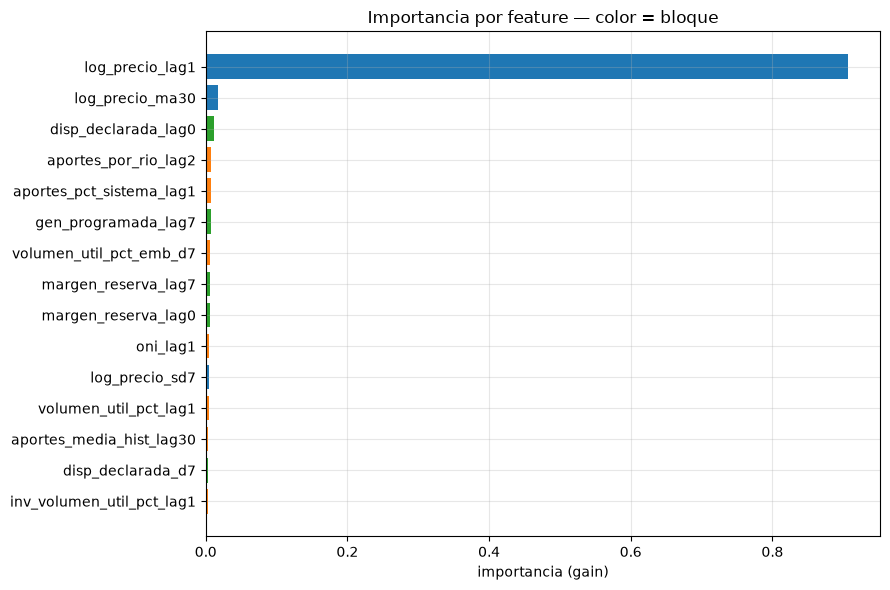

Aporte agregado por bloque:
AR        0.929
HIDRO     0.038
OFERTA    0.034


In [12]:
# Importancia por ganancia, ajustando sobre todo el desarrollo
d = pd.concat([X_dev, y_dev], axis=1).dropna()
m_final = xgb.XGBRegressor(**MEJORES, random_state=CONFIG["seed"],
                           n_jobs=-1, tree_method="hist")
m_final.fit(d[X.columns].values, d["y"].values)

imp = (pd.Series(m_final.feature_importances_, index=X.columns)
         .sort_values(ascending=True))
bloque_de = {f: b for b, lst in FEATURES.items() for f in lst}
colores = {b: plt.cm.tab10.colors[i % 10] for i, b in enumerate(FEATURES)}

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp.index, imp.values,
        color=[colores[bloque_de[f]] for f in imp.index])
ax.set_xlabel("importancia (gain)")
ax.set_title("Importancia por feature — color = bloque")
plt.tight_layout(); plt.show()

print("Aporte agregado por bloque:")
print(imp.groupby(imp.index.map(bloque_de)).sum()
         .sort_values(ascending=False).round(3).to_string())

## 9. Guardar resultados

Las predicciones quedan en disco para compararlas después contra SARIMAX y LSTM
sin tener que volver a entrenar.

In [13]:
out = Path(CONFIG["out_dir"]); out.mkdir(exist_ok=True)

pd.DataFrame({
    "real_log": y.loc[pred_exp.index],
    "real_nivel": y_niv.loc[pred_exp.index],
    "ingenuo": pred_ing,
    "xgb_expansiva": pred_exp,
    "xgb_deslizante": pred_des,
    "rf_referencia": pred_rf,
    "regimen": regimen,
}).to_csv(out / "predicciones_xgboost.csv")

tabla.to_csv(out / "metricas_xgboost_global.csv")
por_reg.to_csv(out / "metricas_xgboost_regimen.csv", index=False)
tabla_dm.to_csv(out / "dm_xgboost.csv", index=False)
extrapolacion.to_csv(out / "extrapolacion_xgboost.csv", index=False)
pd.Series(MEJORES).to_csv(out / "hiperparametros_xgboost.csv")
pd.Series({"modelo_etapa3": INFO_MODELO["modelo"] if INFO_MODELO else "RESPALDO",
           "features": ";".join(X.columns)}).to_csv(out / "features_xgboost.csv")

print(f"Guardado en {out.resolve()}")
print("\nPENDIENTE para cerrar la comparación de la propuesta:")
print("  - SARIMAX con regresores externos (la línea base que exige el documento)")
print("  - LSTM")
print("  - La meta es reducir el MAPE 15% frente a SARIMAX, no frente a RF.")

Guardado en C:\Users\andre\OneDrive\cosas de la universidad\Uniandes\VIII\Tesis\salidas_modelos

PENDIENTE para cerrar la comparación de la propuesta:
  - SARIMAX con regresores externos (la línea base que exige el documento)
  - LSTM
  - La meta es reducir el MAPE 15% frente a SARIMAX, no frente a RF.
